In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/function_host')

In [ ]:
import binance
import research

In [ ]:
import polars as pl
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datetime import datetime, timedelta
import random

import altair as alt

In [ ]:
research.set_seed(42)

In [ ]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)

polars.config.Config

In [ ]:
# Trading pair symbols
sym = 'BTCUSDT'
# Time horizon of time series
time_interval = '1h'
# Max number of auto regressive lag
max_lag = 4
# Forecast horizon in step
forecast_horizon = 1
# Sharpe annualized rate
annualized_rate = research.sharpe_annualization_factor(time_interval,365,24)

In [ ]:
# Get price data
start_date = datetime(2024,10,29,0,0)
end_date = datetime(2025,10,9,00)
binance.download_date_range(sym, start_date, end_date)

In [ ]:
# Load time series
ts = research.load_ohlc_timeseries_range(sym, time_interval, start_date, end_date)
ts

Loading BTCUSDT: 100%|██████████| 346/346 [02:57<00:00,  1.95day/s]


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2024-10-29 00:00:00,69939.9,69998.4,69733.0,69939.5
2024-10-29 01:00:00,69939.5,70399.4,69810.8,70287.0
2024-10-29 02:00:00,70286.9,71607.0,70198.1,71173.9
2024-10-29 03:00:00,71173.8,71409.0,70870.2,70927.5
2024-10-29 04:00:00,70927.4,71123.4,70906.1,71062.6
…,…,…,…,…
2025-10-09 19:00:00,120600.0,121060.1,120600.0,120897.6
2025-10-09 20:00:00,120897.6,121147.2,120787.9,121045.4
2025-10-09 21:00:00,121045.3,121457.2,120998.3,121407.8


In [ ]:
research.load_timeseries_range(sym, time_interval, start_date, end_date, pl.col('price').quantile(0.5).alias('price_median'))

Loading BTCUSDT: 100%|██████████| 346/346 [03:33<00:00,  1.62day/s]


datetime,price_median
datetime[μs],f64
2024-10-29 00:00:00,69848.5
2024-10-29 01:00:00,69969.0
2024-10-29 02:00:00,71180.1
2024-10-29 03:00:00,71170.5
2024-10-29 04:00:00,71029.3
…,…
2025-10-09 19:00:00,120839.8
2025-10-09 20:00:00,120942.8
2025-10-09 21:00:00,121300.7


In [ ]:
ts.describe()

statistic,datetime,open,high,low,close
str,str,f64,f64,f64,f64
"""count""","""8304""",8304.0,8304.0,8304.0,8304.0
"""null_count""","""0""",0.0,0.0,0.0,0.0
"""mean""","""2025-04-19 23:30:00""",100662.226469,100983.084706,100342.412717,100668.43414
"""std""",null,12438.474058,12408.276781,12463.530406,12436.030551
"""min""","""2024-10-29 00:00:00""",67097.1,67620.5,66810.0,67097.0
"""25%""","""2025-01-23 12:00:00""",93720.9,94041.3,93356.6,93726.0
"""50%""","""2025-04-20 00:00:00""",101620.1,101953.0,101223.0,101627.7
"""75%""","""2025-07-15 11:00:00""",109969.0,110280.0,109648.6,109986.7
"""max""","""2025-10-09 23:00:00""",125986.1,126208.5,125185.1,125986.0


In [ ]:
ts.shape

(8304, 5)

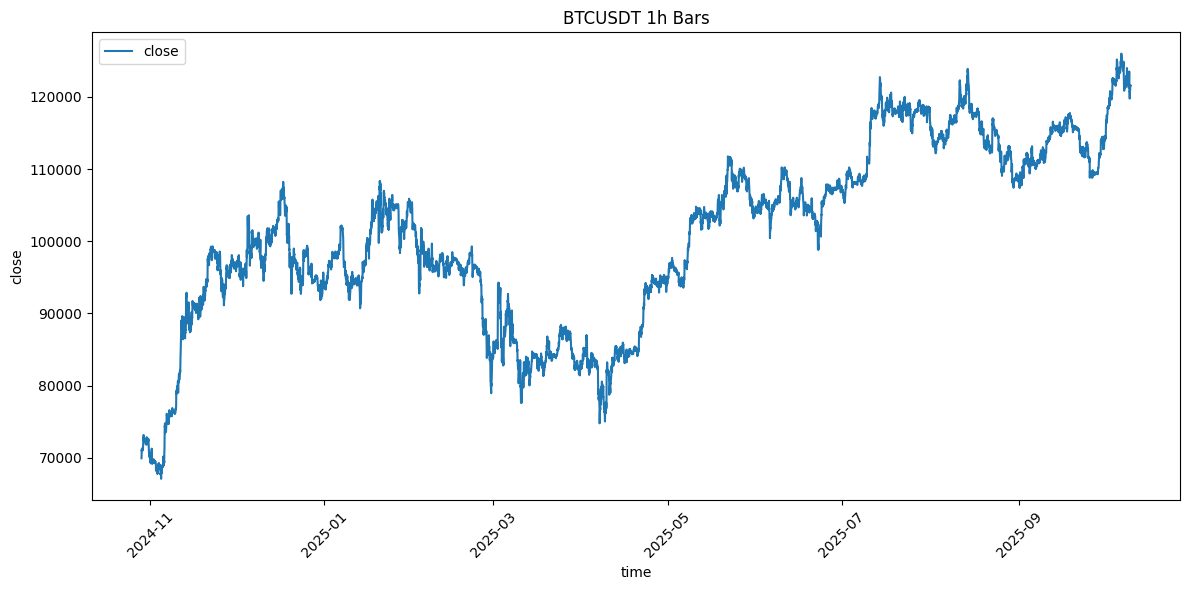

In [ ]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [ ]:
!pip install "vegafusion[embed]>=1.5.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 61.6 MB/s eta 0:00:00


In [ ]:
 !pip install "vl-convert-python>=1.6.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 52.4 MB/s eta 0:00:00


In [ ]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)



alt.Chart(...)

In [ ]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_columns(price_time_series, 'price')

alt.Chart(...)

In [ ]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


In [ ]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

In [ ]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)